# Analyse Exploratoire

### Import des modules

In [111]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import numpy as np

### Analyse Exploratoire

In [112]:
building_consumption = pd.read_csv('./2016_Building_Energy_Benchmarking.csv')

In [113]:
# On regarde comment un batiment est défini dans ce jeu de données 
building_consumption.head()

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,...,Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity
0,1,2016,NonResidential,Hotel,Mayflower park hotel,405 Olive way,Seattle,WA,98101.0,0659000030,...,1.156514e+06,3946027.0,12764.52930,1276453.0,False,NaN,Compliant,NaN,249.98,2.83
1,2,2016,NonResidential,Hotel,Paramount Hotel,724 Pine street,Seattle,WA,98101.0,0659000220,...,9.504252e+05,3242851.0,51450.81641,5145082.0,False,NaN,Compliant,NaN,295.86,2.86
2,3,2016,NonResidential,Hotel,5673-The Westin Seattle,1900 5th Avenue,Seattle,WA,98101.0,0659000475,...,1.451544e+07,49526664.0,14938.00000,1493800.0,False,NaN,Compliant,NaN,2089.28,2.19
3,5,2016,NonResidential,Hotel,HOTEL MAX,620 STEWART ST,Seattle,WA,98101.0,0659000640,...,8.115253e+05,2768924.0,18112.13086,1811213.0,False,NaN,Compliant,NaN,286.43,4.67
4,8,2016,NonResidential,Hotel,WARWICK SEATTLE HOTEL (ID8),401 LENORA ST,Seattle,WA,98121.0,0659000970,...,1.573449e+06,5368607.0,88039.98438,8803998.0,False,NaN,Compliant,NaN,505.01,2.88


In [114]:
# On regarde le nombre de valeurs manquantes par colonne ainsi que leur type 
building_consumption.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3376 entries, 0 to 3375
Data columns (total 46 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   OSEBuildingID                    3376 non-null   int64  
 1   DataYear                         3376 non-null   int64  
 2   BuildingType                     3376 non-null   object 
 3   PrimaryPropertyType              3376 non-null   object 
 4   PropertyName                     3376 non-null   object 
 5   Address                          3376 non-null   object 
 6   City                             3376 non-null   object 
 7   State                            3376 non-null   object 
 8   ZipCode                          3360 non-null   float64
 9   TaxParcelIdentificationNumber    3376 non-null   object 
 10  CouncilDistrictCode              3376 non-null   int64  
 11  Neighborhood                     3376 non-null   object 
 12  Latitude            

In [115]:
building_consumption['ComplianceStatus'].unique()

array(['Compliant', 'Error - Correct Default Data', 'Missing Data',
       'Non-Compliant'], dtype=object)

#### TERMINER L'ANALYSE EXPLORATOIRE 

A réaliser : 
- Une analyse descriptive des données, y compris une explication du sens des colonnes gardées, des arguments derrière la suppression de lignes ou de colonnes, des statistiques descriptives et des visualisations pertinentes.

Quelques pistes d'analyse : 

* Identifier les colonnes avec une majorité de valeurs manquantes ou constantes en utilisant la méthode value_counts() de Pandas
* Mettre en evidence les différences entre les immeubles mono et multi-usages
* Utiliser des pairplots et des boxplots pour faire ressortir les outliers ou des batiments avec des valeurs peu cohérentes d'un point de vue métier 

Pour vous inspirer, ou comprendre l'esprit recherché dans une analyse exploratoire, vous pouvez consulter ce notebook en ligne : https://www.kaggle.com/code/pmarcelino/comprehensive-data-exploration-with-python. Il ne s'agit pas d'un modèle à suivre à la lettre ni d'un template d'analyses attendues pour ce projet. 

In [116]:
BuildingType_To_Keep = [
    'NonResidential',
    'Nonresidential COS',
    'SPS-District K-12',
    'Campus',
    'Nonresidential WA'
]
compliance_To_Keep =[
    'Compliant',
    'Missing Data']


NR_building_consumption = building_consumption.loc[building_consumption['BuildingType'].isin(BuildingType_To_Keep)]
NR_building_consumption = NR_building_consumption[building_consumption['ComplianceStatus'].isin(compliance_To_Keep)]
NR_building_consumption.shape


C:\Users\Fabien\AppData\Local\Temp\ipykernel_37088\2096516383.py:14: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  NR_building_consumption = NR_building_consumption[building_consumption['ComplianceStatus'].isin(compliance_To_Keep)]


(1562, 46)

In [117]:
def quantile_outliers(column):
    q1 = column.quantile(0.25)
    q3 = column.quantile(0.75)

    iqr = q3 - q1

    low_limite = q1 - 1.5 *iqr
    high_limite = q3 + 1.5 * iqr
    return [low_limite,high_limite]

In [118]:
outlier_columns = ['GHGEmissionsIntensity','TotalGHGEmissions','PropertyGFABuilding(s)','NumberofFloors']

for column in outlier_columns:
    limite_basse, limite_haute = quantile_outliers(NR_building_consumption[column])
    NR_building_consumption = NR_building_consumption[(NR_building_consumption[column]>limite_basse) & (NR_building_consumption[column]<limite_haute)]
    print(NR_building_consumption.shape)

(1427, 46)
(1266, 46)
(1152, 46)
(1060, 46)


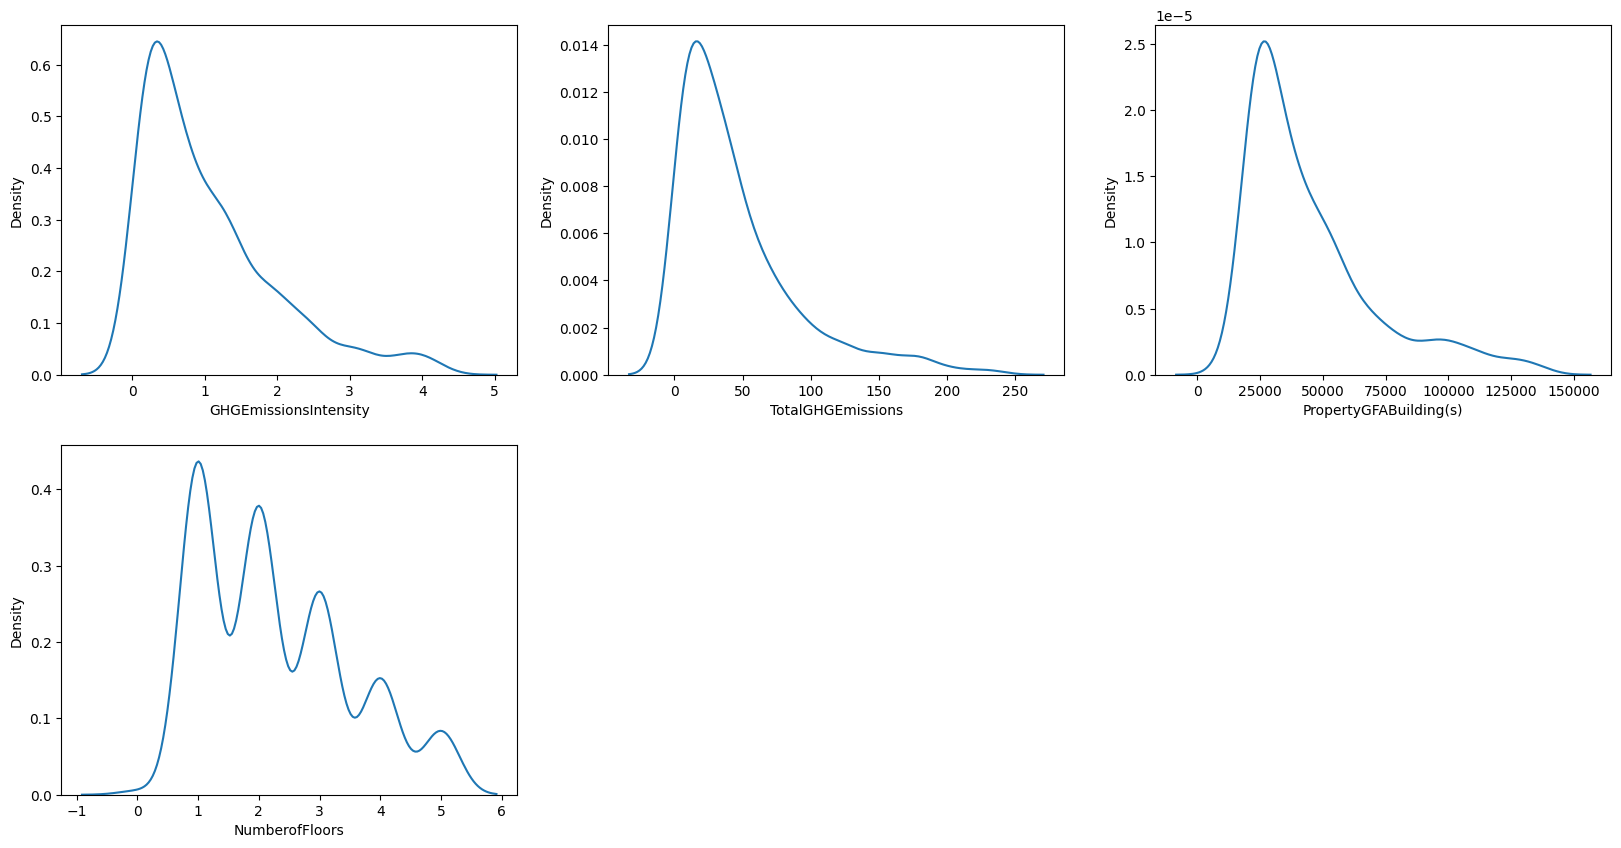

In [119]:
plt.figure(figsize=(20,10))
for i,column in enumerate(outlier_columns):
    plt.subplot(int(len(outlier_columns)/3)+1,3,i+1)
    sns.kdeplot(data=NR_building_consumption[column])


In [120]:
NR_building_consumption.head()

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,...,Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity
25,31,2016,NonResidential,Other,Seattle Honda,1015 & 1017 Olive Way,Seattle,WA,98101.0,0660001725,...,384008.3125,1310236.0,0.00000,0.0,False,NaN,Compliant,NaN,9.13,0.14
28,34,2016,SPS-District K-12,K-12 School,Meany Building,301/300 21st Ave. E.,Seattle,WA,98112.0,0688000090,...,0.0000,0.0,0.00000,0.0,False,NaN,Missing Data,NaN,0.00,0.00
29,35,2016,NonResidential,Hotel,Hotel Five,2200 5th ave,Seattle,WA,98121.0,0697000170,...,687675.6250,2346349.0,21103.65039,2110365.0,False,NaN,Compliant,NaN,128.44,1.88
31,37,2016,SPS-District K-12,K-12 School,John Hay Elementary,201 Garfield St.,Seattle,WA,98109.0,0809000005,...,438691.6875,1496816.0,0.00000,0.0,False,NaN,Missing Data,NaN,10.43,0.20
32,38,2016,NonResidential,Small- and Mid-Sized Office,Good Shepherd Center,4649 Sunnyside Ave. N.,Seattle,WA,98070.0,0825049008,...,396495.6875,1352843.0,27930.77148,2793077.0,False,NaN,Compliant,NaN,157.77,1.81


In [121]:
columns_to_drop = ['TaxParcelIdentificationNumber','ZipCode','Address','PropertyName','DataYear','City','State','Outlier', 'ComplianceStatus' , 'Comments' , 'NaturalGas(therms)' ,'DefaultData' ,'Electricity(kWh)' ,'SourceEUIWN(kBtu/sf)','SourceEUI(kBtu/sf)','YearsENERGYSTARCertified']
NR_building_consumption.drop(columns_to_drop, axis=1, inplace=True)
NR_building_consumption.shape

(1060, 30)

- 'TaxParcelIdentificationNumber','ZipCode','Address','PropertyName','DataYear','City','State','Outlier', 'ComplianceStatus' , 'Comments' ,'DefaultData' = valeur constante ou ne servent à rien  
- 'NaturalGas(therms)' , 'Electricity(kWh)' = Doublon avec la valeur en kBtu  
- 'SourceEUIWN(kBtu/sf)','SourceEUI(kBtu/sf)' = doublon avec les siteEnergyuse  
- 'YearsENERGYSTARCertified' = trop de Na  


In [122]:
NR_building_consumption= NR_building_consumption[NR_building_consumption['SiteEUIWN(kBtu/sf)'].notna()]
NR_building_consumption.shape

(1060, 30)

**Décision :** Variable cible = **TotalGHGEmissions**

## Prouver la relation entre les energies et le CO²

(0.0, 7000000.0)

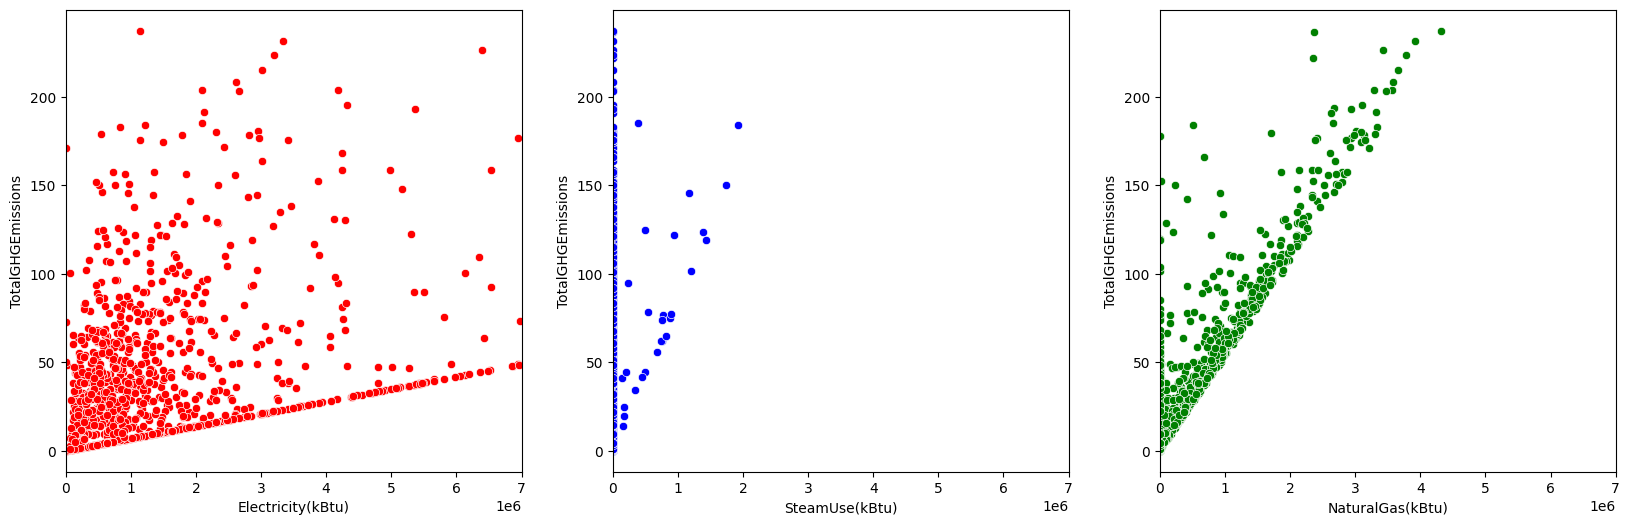

In [123]:
plt.figure(figsize=(20,6))
plt.subplot(1,3,1)
sns.scatterplot(data=NR_building_consumption, x='Electricity(kBtu)', y='TotalGHGEmissions', c='red')
plt.xlim(0,7000000)
plt.subplot(1,3,2)
sns.scatterplot(data=NR_building_consumption, x='SteamUse(kBtu)', y='TotalGHGEmissions', c ='blue')
plt.xlim(0,7000000)
plt.subplot(1,3,3)
sns.scatterplot(data=NR_building_consumption, x='NaturalGas(kBtu)', y='TotalGHGEmissions', c ='green')
plt.xlim(0,7000000)

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20],
 [Text(0, 0, 'Other'),
  Text(1, 0, 'K-12 School'),
  Text(2, 0, 'Hotel'),
  Text(3, 0, 'Small- and Mid-Sized Office'),
  Text(4, 0, 'Self-Storage Facility'),
  Text(5, 0, 'Retail Store'),
  Text(6, 0, 'University'),
  Text(7, 0, 'Residence Hall'),
  Text(8, 0, 'Warehouse'),
  Text(9, 0, 'Mixed Use Property'),
  Text(10, 0, 'Senior Care Community'),
  Text(11, 0, 'Worship Facility'),
  Text(12, 0, 'Large Office'),
  Text(13, 0, 'Distribution Center'),
  Text(14, 0, 'Medical Office'),
  Text(15, 0, 'Supermarket / Grocery Store'),
  Text(16, 0, 'Refrigerated Warehouse'),
  Text(17, 0, 'Low-Rise Multifamily'),
  Text(18, 0, 'Restaurant'),
  Text(19, 0, 'Laboratory'),
  Text(20, 0, 'Hospital')])

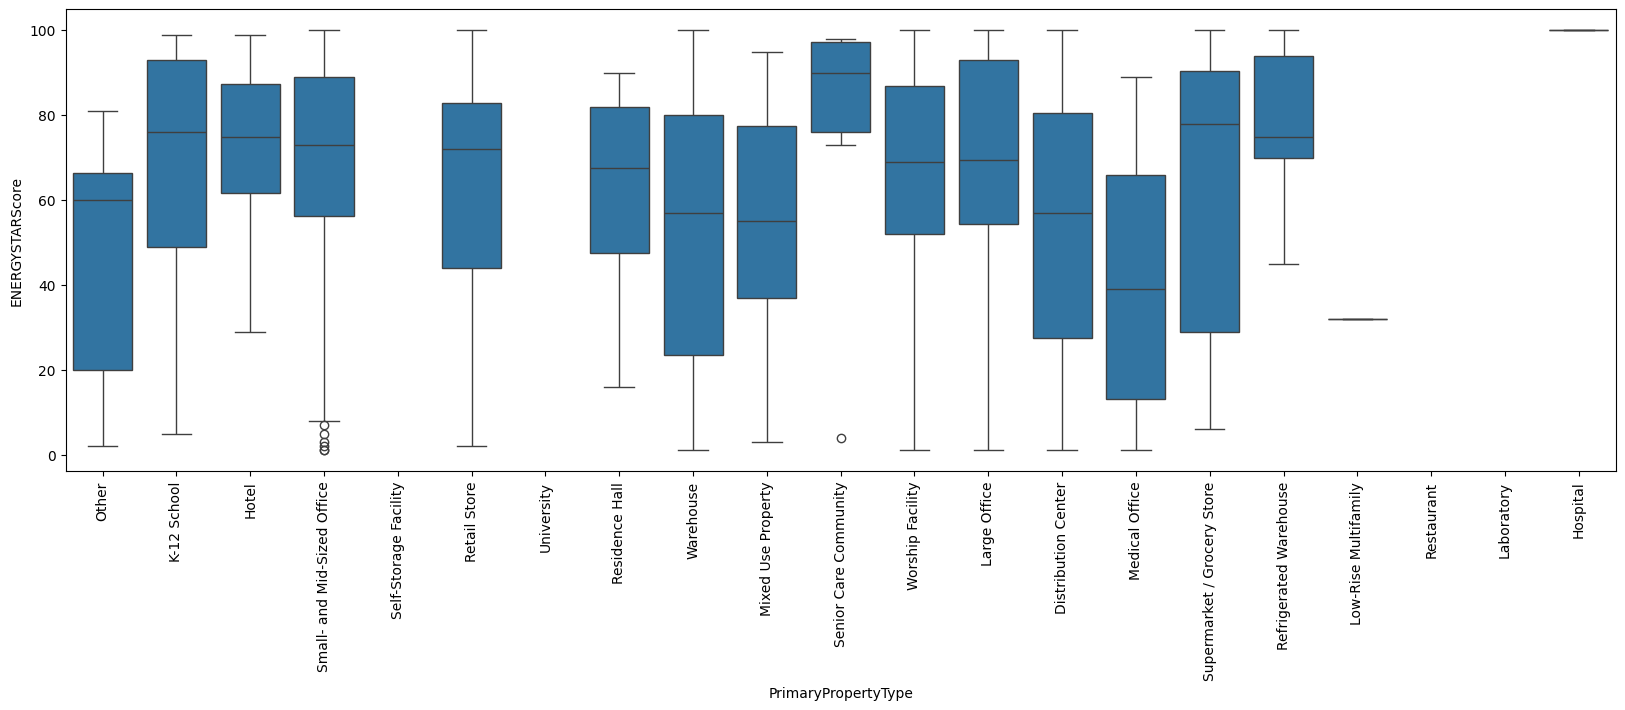

In [124]:
plt.figure(figsize=(20,6))
sns.boxplot(data= NR_building_consumption, x='PrimaryPropertyType', y='ENERGYSTARScore')
plt.xticks(rotation=90)

**Conclusion :** Il y a une forte corrélation entre la consommation des énergies et le CO²  
On peut aussi deviner que la vapeur emet plus que le gaz qui lui même emet plus que l'electricité 

In [125]:
# ['DOWNTOWN', 'NORTHEAST', 'Central', 'MAGNOLIA / QUEEN ANNE',
#        'BALLARD', 'GREATER DUWAMISH', 'LAKE UNION', 'CENTRAL',
#        'SOUTHWEST', 'DELRIDGE', 'EAST', 'SOUTHEAST', 'NORTHWEST', 'NORTH',
#        'North', 'Delridge', 'Ballard', 'Northwest',
#        'DELRIDGE NEIGHBORHOODS']
NR_building_consumption['Neighborhood'] = NR_building_consumption['Neighborhood'].str.upper()
NR_building_consumption.loc[NR_building_consumption['Neighborhood']=='DELRIDGE NEIGHBORHOODS','Neighborhood'] = 'DELRIDGE'
NR_building_consumption['Neighborhood'].unique()

array(['DOWNTOWN', 'CENTRAL', 'MAGNOLIA / QUEEN ANNE', 'LAKE UNION',
       'NORTHEAST', 'BALLARD', 'GREATER DUWAMISH', 'EAST', 'SOUTHWEST',
       'DELRIDGE', 'SOUTHEAST', 'NORTHWEST', 'NORTH'], dtype=object)

# Modélisation 

### Import des modules 

In [126]:
#Selection
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV, 
    cross_validate,
)
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error 
from sklearn.inspection import permutation_importance

#Preprocess
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler, MinMaxScaler

#Modèles
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor


## Encodage des variable qualitatives

In [127]:
OHE_BuildingType = OneHotEncoder(handle_unknown='ignore',sparse_output=False).set_output(transform='pandas')
encoded_df =OHE_BuildingType.fit_transform(NR_building_consumption[['BuildingType']])
NR_building_consumption = pd.concat([NR_building_consumption,encoded_df.astype(bool)],axis=1).drop('BuildingType', axis=1)


In [128]:
OHE_PrimaryPropertyType = OneHotEncoder(sparse_output=False, handle_unknown='ignore').set_output(transform='pandas')
encoded_df = OHE_PrimaryPropertyType.fit_transform(NR_building_consumption[['PrimaryPropertyType']])
NR_building_consumption = pd.concat([NR_building_consumption,encoded_df.astype(bool)],axis=1).drop(columns = 'PrimaryPropertyType')

In [129]:
OHE_Neighborhood = OneHotEncoder(sparse_output=False, handle_unknown='ignore').set_output(transform='pandas')
encoded_df = OHE_Neighborhood.fit_transform(NR_building_consumption[['Neighborhood']])
NR_building_consumption = pd.concat([NR_building_consumption,encoded_df.astype(bool)],axis=1).drop(columns = 'Neighborhood')

In [130]:
NR_building_consumption.shape

(1060, 66)

# Feature Engineering

A réaliser : Enrichir le jeu de données actuel avec de nouvelles features issues de celles existantes. 

En règle générale : On utilise la méthode .apply() de Pandas pour créer une nouvelle colonne à partir d'une colonne existante. N'hésitez pas à regarder les exemples dans les chapitres de cours donnés en ressource

## Traitement des données contre le dataLeakage

In [131]:
# Création de HasElectricity , HasSteam , HasGas , isMultiUsage, hasParking
NR_building_consumption['HasElectricity'] = NR_building_consumption['Electricity(kBtu)'] > 0
NR_building_consumption['HasSteam'] = NR_building_consumption['SteamUse(kBtu)'] > 0
NR_building_consumption['HasGas'] = NR_building_consumption['NaturalGas(kBtu)'] > 0
NR_building_consumption['isMultiUsage'] = NR_building_consumption['SecondLargestPropertyUseType'].notna()
NR_building_consumption['HasParking'] = NR_building_consumption['PropertyGFAParking'] > 0


In [132]:
dataLeakage_cols =['SiteEUI(kBtu/sf)','SiteEUIWN(kBtu/sf)','SiteEnergyUse(kBtu)','SiteEnergyUseWN(kBtu)','SteamUse(kBtu)','Electricity(kBtu)','NaturalGas(kBtu)']
NR_building_consumption.drop(dataLeakage_cols,axis=1,inplace=True)
NR_building_consumption.head()

,OSEBuildingID,CouncilDistrictCode,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),...,Neighborhood_NORTH,Neighborhood_NORTHEAST,Neighborhood_NORTHWEST,Neighborhood_SOUTHEAST,Neighborhood_SOUTHWEST,HasElectricity,HasSteam,HasGas,isMultiUsage,HasParking
25,31,7,47.61500,-122.33081,1930,1.0,2,67224,0,67224,...,False,False,False,False,False,True,False,False,False,False
28,34,3,47.62266,-122.30547,1955,1.0,1,126351,0,126351,...,False,False,False,False,False,False,False,False,False,False
29,35,7,47.61558,-122.34186,1978,1.0,5,68410,16200,52210,...,False,False,False,False,False,True,False,True,False,True
31,37,7,47.63290,-122.35172,1989,1.0,2,51582,0,51582,...,False,False,False,False,False,True,False,False,False,False
32,38,4,47.66410,-122.33118,1906,1.0,3,87262,0,87262,...,False,False,False,False,False,True,False,True,True,False


# Préparation des features pour la modélisation

A réaliser :
* ~~Si ce n'est pas déjà fait, supprimer toutes les colonnes peu pertinentes pour la modélisation.~~
* ~~Tracer la distribution de la cible pour vous familiariser avec l'ordre de grandeur. En cas d'outliers, mettez en place une démarche pour les supprimer.~~
* ~~Débarrassez-vous des features redondantes en utilisant une matrice de corrélation de Pearson. Pour cela, utiisez la méthode corr() de Pandas, couplé d'un graphique Heatmap de la librairie Seaborn~~
* ~~Réalisez différents graphiques pour comprendre le lien entre vos features et la target (boxplots, scatterplots, pairplot si votre nombre de features numériques n'est pas très élevé).~~
* ~~Séparez votre jeu de données en un Pandas DataFrame X (ensemble de features) et Pandas Series y (votre target).~~
* ~~Si vous avez des features catégorielles, il faut les encoder pour que votre modèle fonctionne. Les deux méthodes d'encodage à connaitre sont le OneHotEncoder et le LabelEncoder~~

## Distribution de la valeur cible **TotalGHGEmissions**

<Axes: xlabel='TotalGHGEmissions', ylabel='Count'>

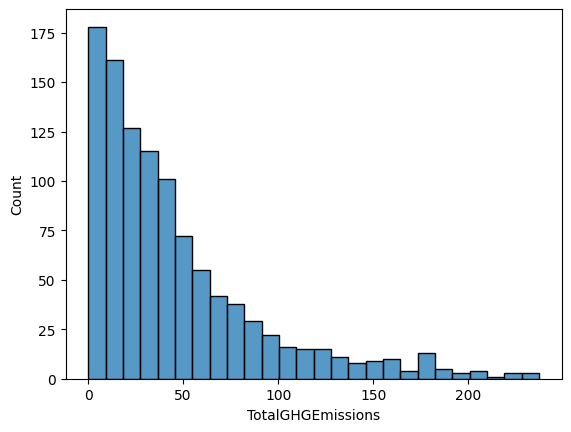

In [133]:
sns.histplot(data= NR_building_consumption['TotalGHGEmissions'])


## Analyse par matrice de correlation et suppression des variables redondantes

In [134]:
redundante_cols = ['OSEBuildingID','GHGEmissionsIntensity','PropertyGFATotal','LargestPropertyUseTypeGFA','PropertyGFAParking','SecondLargestPropertyUseTypeGFA','ThirdLargestPropertyUseTypeGFA','ListOfAllPropertyUseTypes','LargestPropertyUseType','SecondLargestPropertyUseType','ThirdLargestPropertyUseType']
NR_building_consumption.drop(redundante_cols, axis=1,inplace= True)

<Axes: >

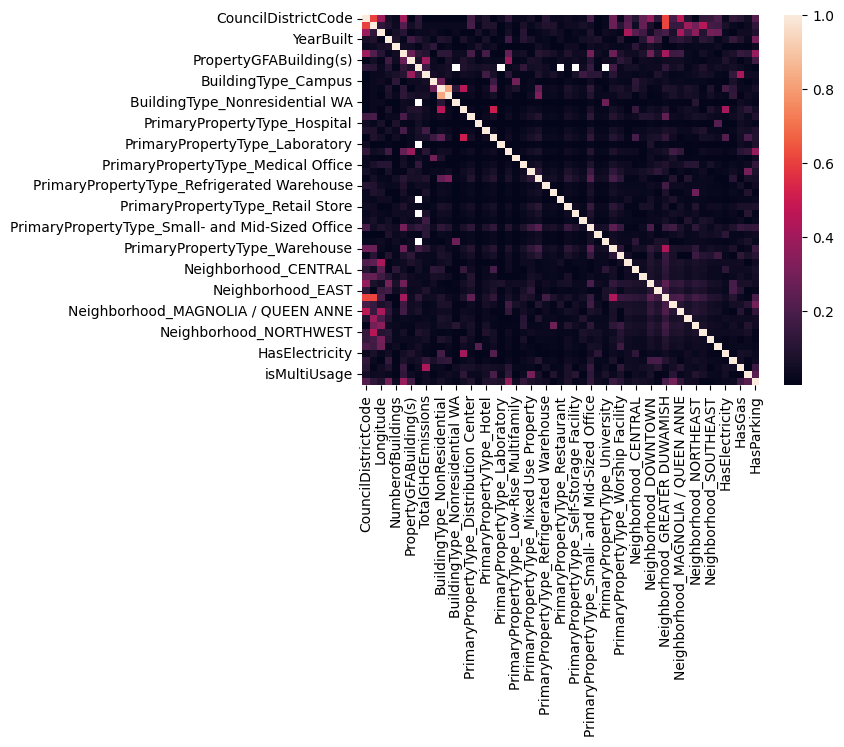

In [135]:
features_numerique = NR_building_consumption.columns[NR_building_consumption.dtypes != object]
corr_mat  = NR_building_consumption[features_numerique].corr().abs()
sns.heatmap(corr_mat,annot=False)

Index(['TotalGHGEmissions', 'HasGas', 'PropertyGFABuilding(s)',
       'PrimaryPropertyType_Hotel',
       'PrimaryPropertyType_Senior Care Community', 'ENERGYSTARScore',
       'HasSteam', 'PrimaryPropertyType_Small- and Mid-Sized Office',
       'PrimaryPropertyType_Supermarket / Grocery Store',
       'PrimaryPropertyType_Warehouse', 'PrimaryPropertyType_Large Office',
       'NumberofFloors', 'PrimaryPropertyType_Other', 'Neighborhood_EAST',
       'PrimaryPropertyType_Self-Storage Facility', 'NumberofBuildings',
       'PrimaryPropertyType_Residence Hall', 'PrimaryPropertyType_K-12 School',
       'Neighborhood_NORTHWEST', 'BuildingType_Nonresidential COS'],
      dtype='object')


<Axes: >

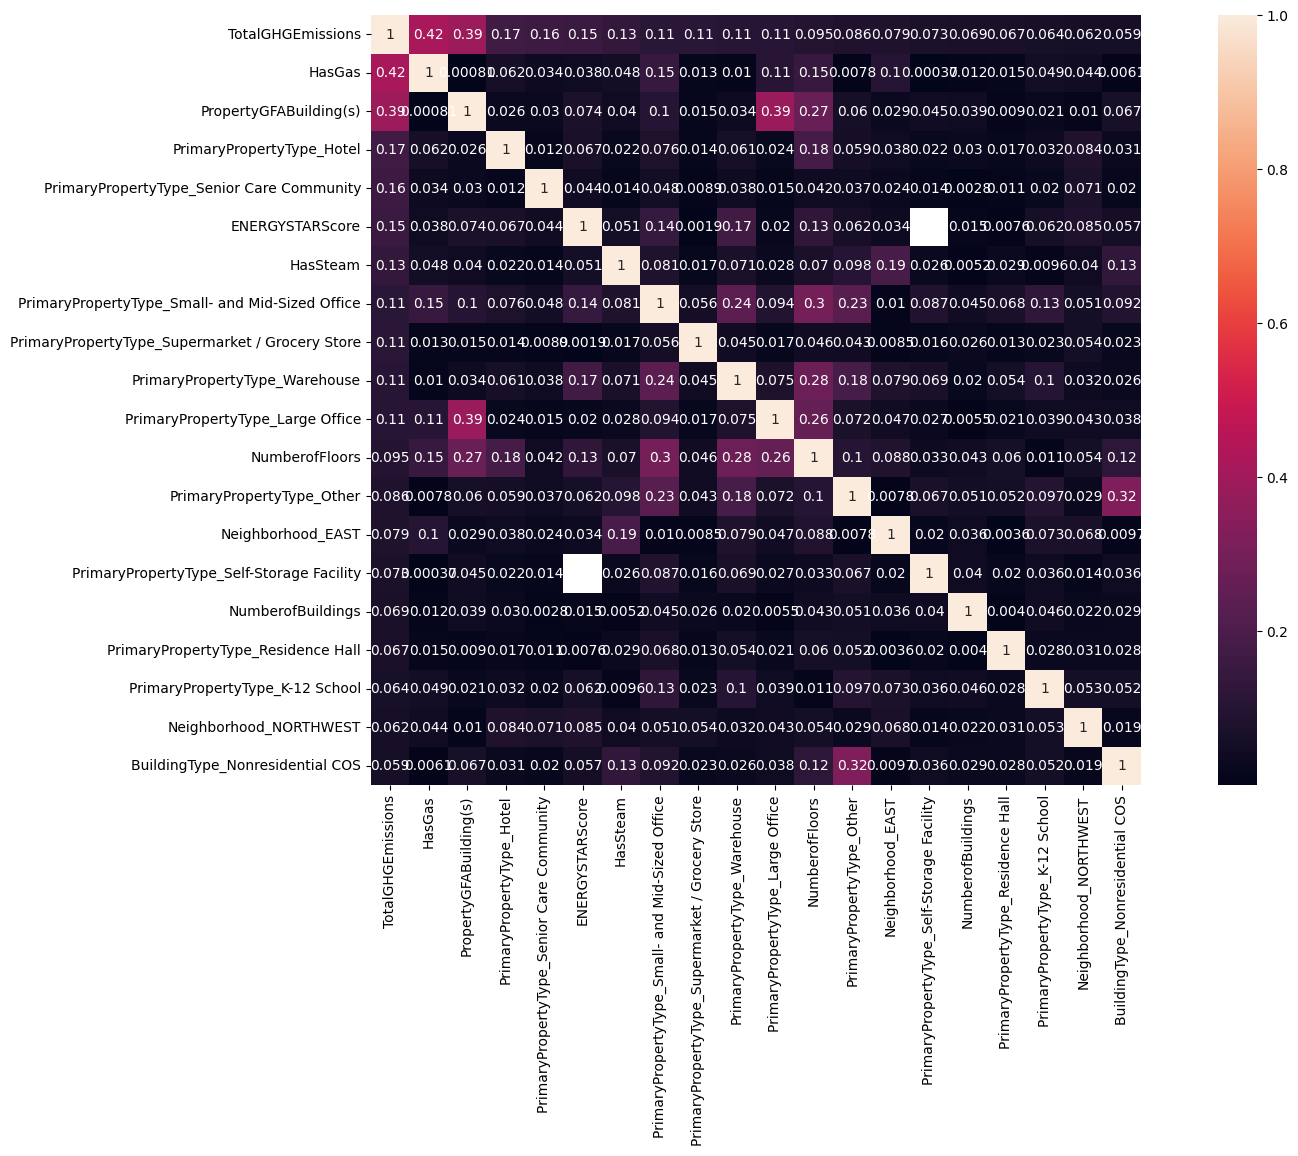

In [136]:
top_cols = corr_mat.nlargest(20,['TotalGHGEmissions'])['TotalGHGEmissions'].index
print(top_cols)
top_cols_corr = NR_building_consumption[top_cols].corr().abs()
plt.figure(figsize=(20,10))
sns.heatmap(data = top_cols_corr,annot=True, square=True)


## Pairplot des variables quantitatives

In [137]:
variables_pairplot = NR_building_consumption.loc[:,(NR_building_consumption.dtypes == int) | (NR_building_consumption.dtypes == float)]


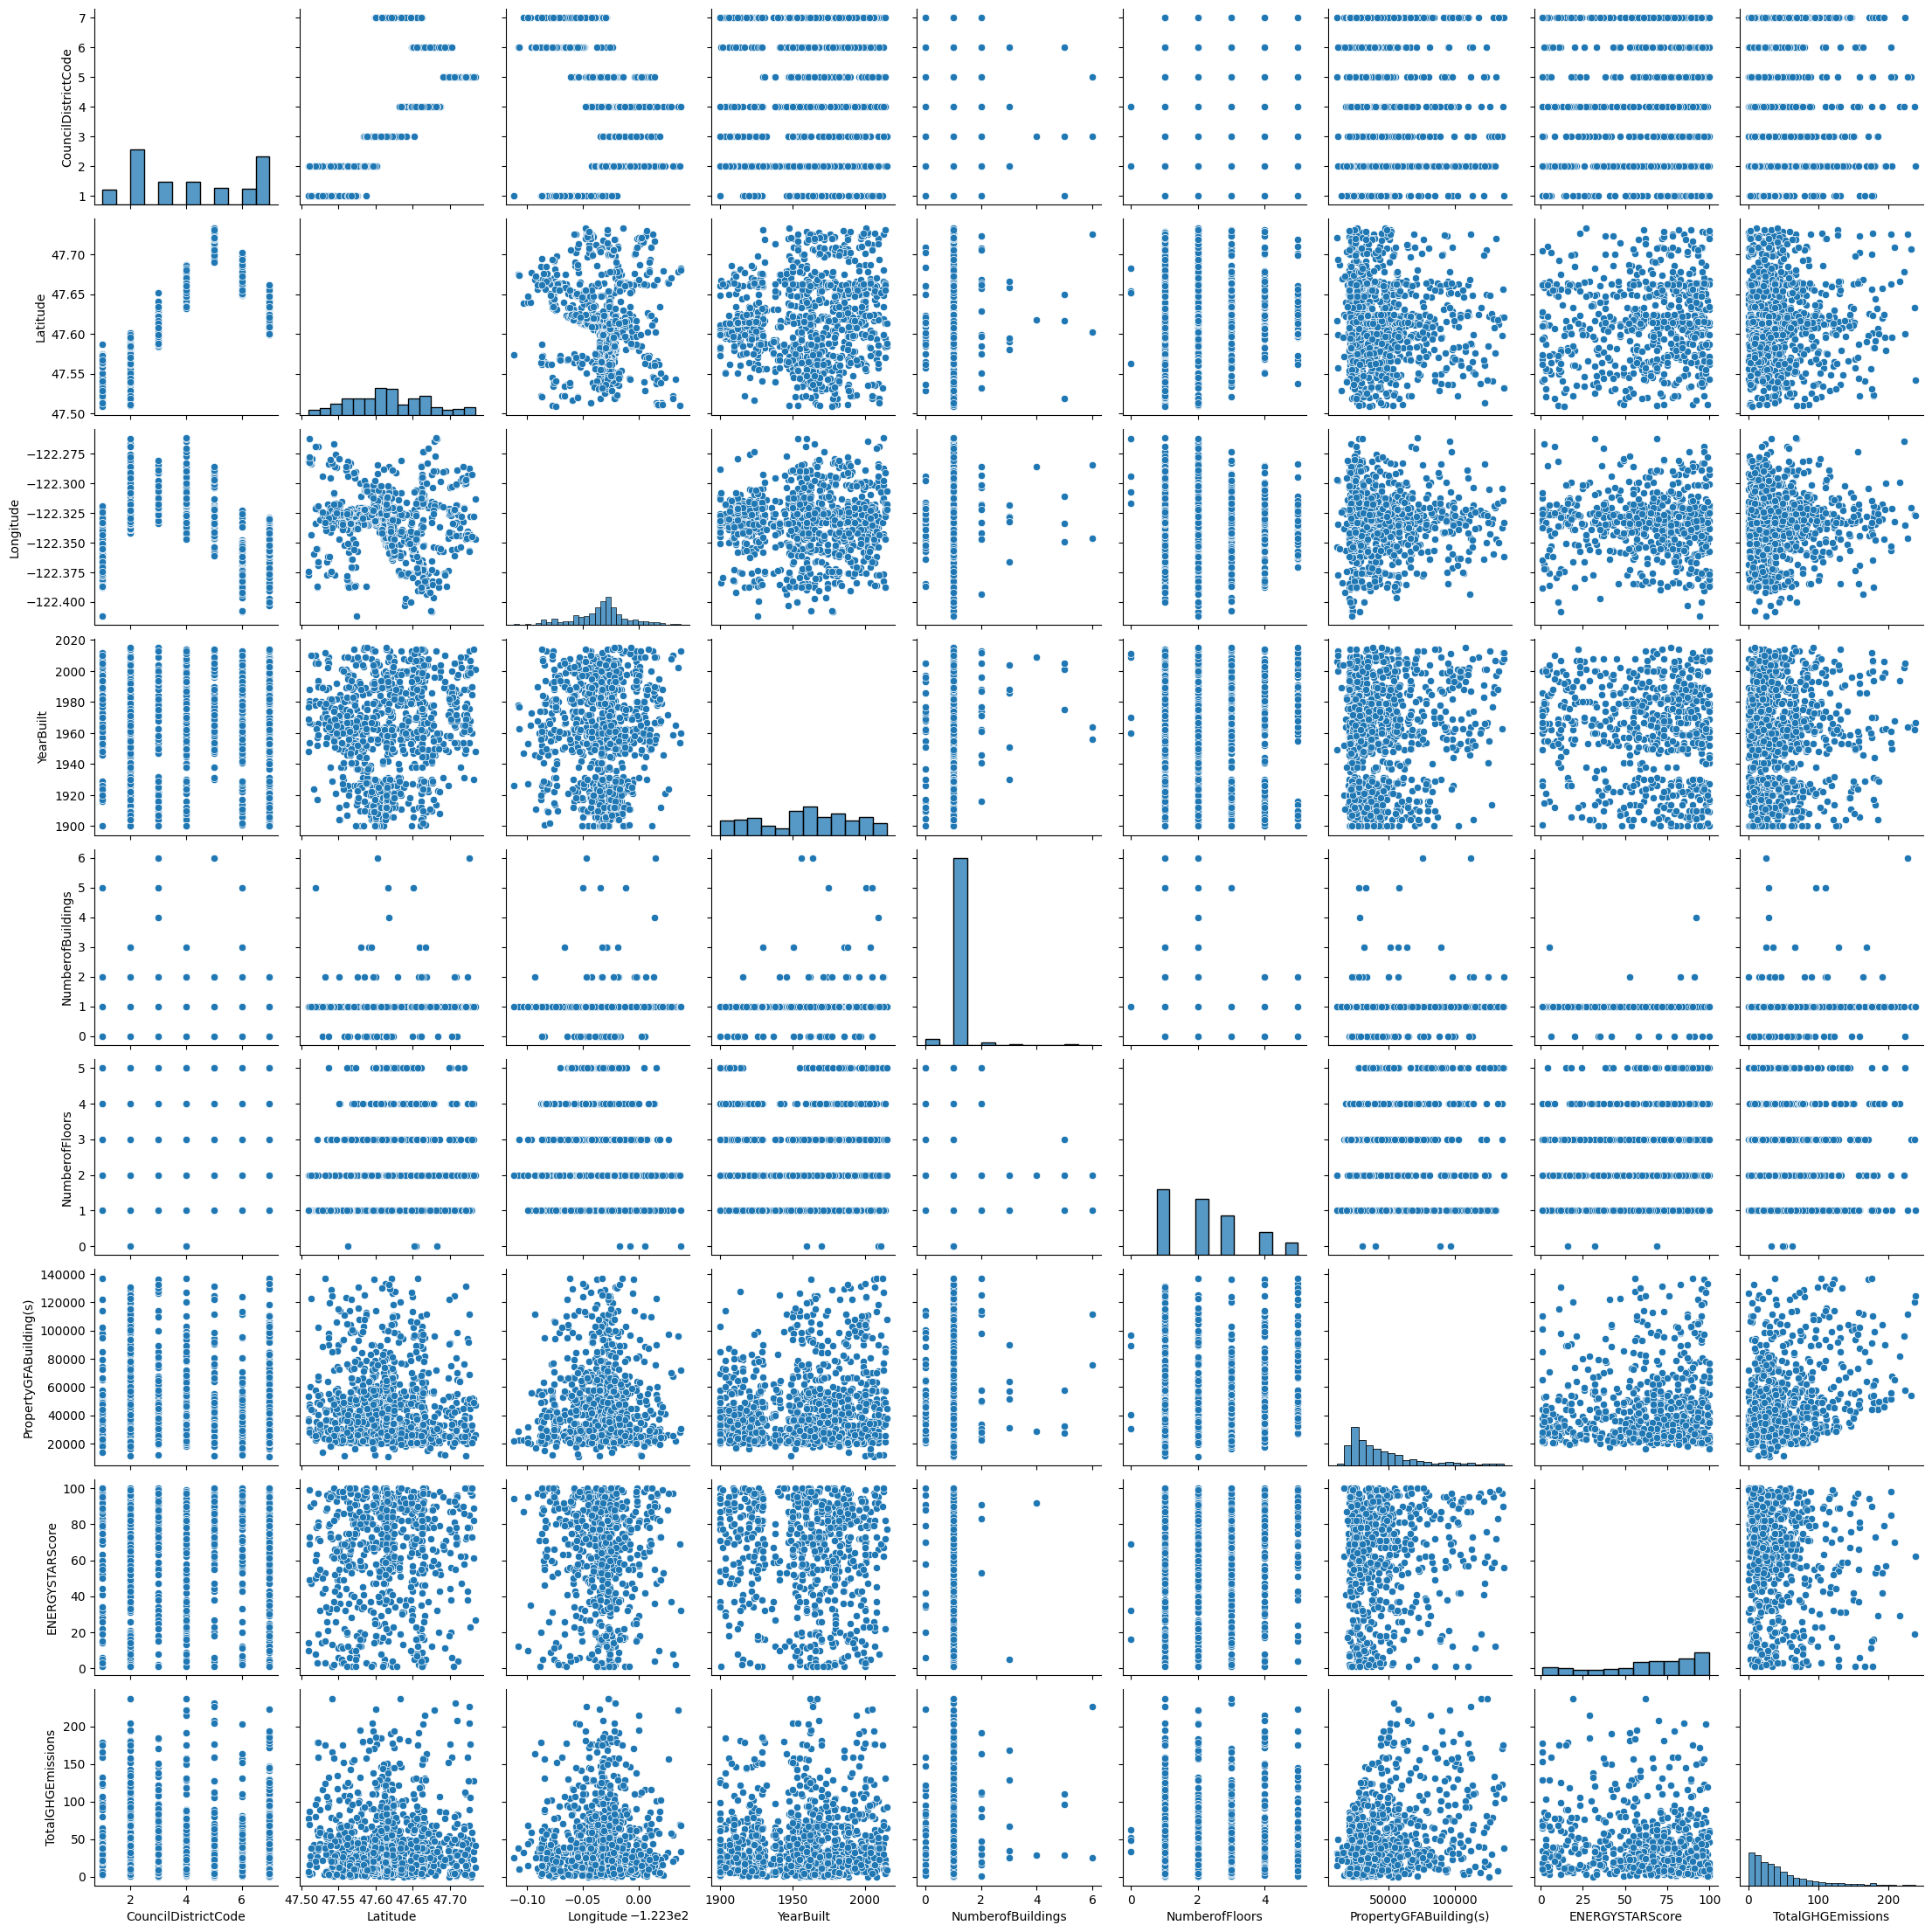

In [138]:
sns.pairplot(data=variables_pairplot)

## Visualisation des variable qualitatives

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20],
 [Text(0, 0, 'PrimaryPropertyType_Distribution Center'),
  Text(1, 0, 'PrimaryPropertyType_Hospital'),
  Text(2, 0, 'PrimaryPropertyType_Hotel'),
  Text(3, 0, 'PrimaryPropertyType_K-12 School'),
  Text(4, 0, 'PrimaryPropertyType_Laboratory'),
  Text(5, 0, 'PrimaryPropertyType_Large Office'),
  Text(6, 0, 'PrimaryPropertyType_Low-Rise Multifamily'),
  Text(7, 0, 'PrimaryPropertyType_Medical Office'),
  Text(8, 0, 'PrimaryPropertyType_Mixed Use Property'),
  Text(9, 0, 'PrimaryPropertyType_Other'),
  Text(10, 0, 'PrimaryPropertyType_Refrigerated Warehouse'),
  Text(11, 0, 'PrimaryPropertyType_Residence Hall'),
  Text(12, 0, 'PrimaryPropertyType_Restaurant'),
  Text(13, 0, 'PrimaryPropertyType_Retail Store'),
  Text(14, 0, 'PrimaryPropertyType_Self-Storage Facility'),
  Text(15, 0, 'PrimaryPropertyType_Senior Care Community'),
  Text(16, 0, 'PrimaryPropertyType_Small- and Mid-Sized Office'),
  Text(17, 0, 'Primar

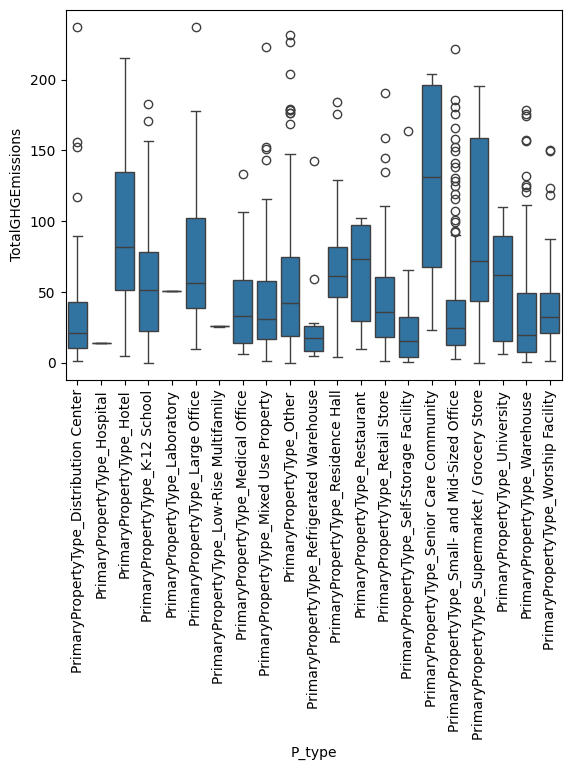

In [139]:
PrimaryPropertyType_cols = []
for col in NR_building_consumption.columns:
    if col.startswith('PrimaryPropertyType'):
        PrimaryPropertyType_cols.append(col)
        
df_PrimaryPropertyType = NR_building_consumption.melt(id_vars='TotalGHGEmissions',
                                                      value_name='Presence',
                                                      var_name='P_type',
                                                      value_vars=PrimaryPropertyType_cols)
df_PrimaryPropertyType = df_PrimaryPropertyType[df_PrimaryPropertyType['Presence']==True]
sns.boxplot(data=df_PrimaryPropertyType, x='P_type', y='TotalGHGEmissions')
plt.xticks(rotation=90)


**Conclusion :** On constate que le type de batiment fait fortement varier la production de CO²

([0, 1, 2],
 [Text(0, 0, 'HasElectricity'), Text(1, 0, 'HasSteam'), Text(2, 0, 'HasGas')])

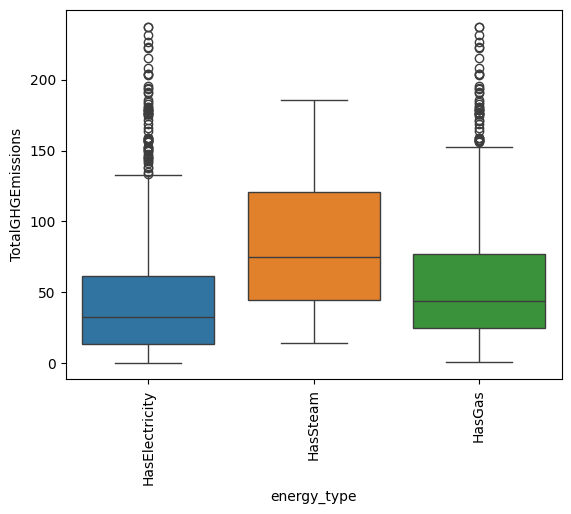

In [140]:
energy_cols = ['HasElectricity','HasSteam','HasGas']
        
df_HasEnergy = NR_building_consumption.melt(id_vars='TotalGHGEmissions',
                                                      value_name='Presence',
                                                      var_name='energy_type',
                                                      value_vars=energy_cols)
df_HasEnergy = df_HasEnergy[df_HasEnergy['Presence']==True]
sns.boxplot(data=df_HasEnergy, x='energy_type', y='TotalGHGEmissions', hue='energy_type')
plt.xticks(rotation=90)

**Conclusion :** On constate que les batiements aillant de la vapeur produisent plus de CO²

([0, 1, 2],
 [Text(0, 0, 'HasElectricity'), Text(1, 0, 'HasSteam'), Text(2, 0, 'HasGas')])

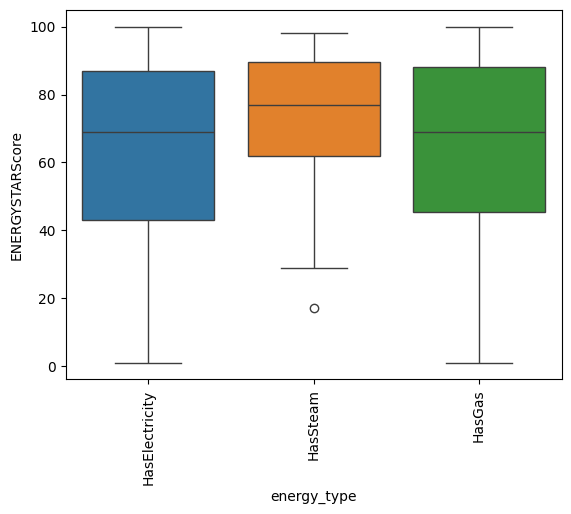

In [141]:
df_HasEnergy = NR_building_consumption.melt(id_vars='ENERGYSTARScore',
                                                      value_name='Presence',
                                                      var_name='energy_type',
                                                      value_vars=energy_cols)
df_HasEnergy = df_HasEnergy[df_HasEnergy['Presence']==True]
sns.boxplot(data=df_HasEnergy, x='energy_type', y='ENERGYSTARScore', hue='energy_type')
plt.xticks(rotation=90)

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
 [Text(0, 0, 'Neighborhood_BALLARD'),
  Text(1, 0, 'Neighborhood_CENTRAL'),
  Text(2, 0, 'Neighborhood_DELRIDGE'),
  Text(3, 0, 'Neighborhood_DOWNTOWN'),
  Text(4, 0, 'Neighborhood_EAST'),
  Text(5, 0, 'Neighborhood_GREATER DUWAMISH'),
  Text(6, 0, 'Neighborhood_LAKE UNION'),
  Text(7, 0, 'Neighborhood_MAGNOLIA / QUEEN ANNE'),
  Text(8, 0, 'Neighborhood_NORTH'),
  Text(9, 0, 'Neighborhood_NORTHEAST'),
  Text(10, 0, 'Neighborhood_NORTHWEST'),
  Text(11, 0, 'Neighborhood_SOUTHEAST'),
  Text(12, 0, 'Neighborhood_SOUTHWEST')])

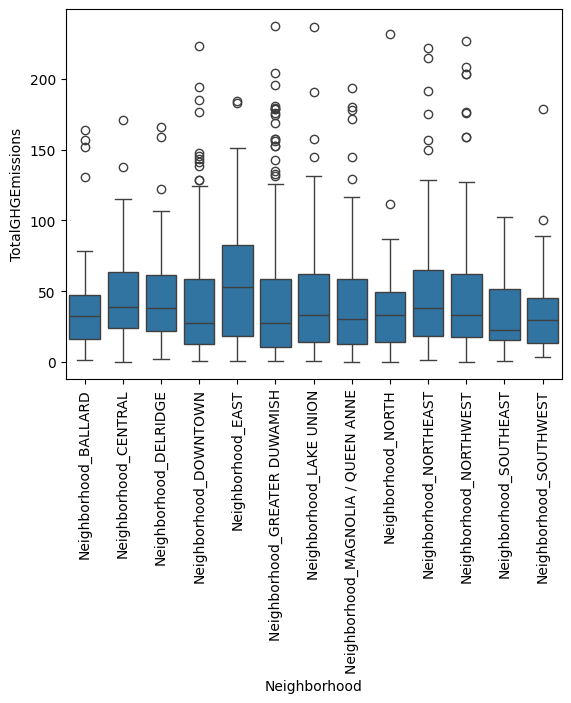

In [142]:
Neighborhood_cols = []
for col in NR_building_consumption.columns:
    if col.startswith('Neighborhood'):
        Neighborhood_cols.append(col)
        
df_Neighborhood = NR_building_consumption.melt(id_vars='TotalGHGEmissions',
                                                      value_name='Presence',
                                                      var_name='Neighborhood',
                                                      value_vars=Neighborhood_cols)
df_Neighborhood = df_Neighborhood[df_Neighborhood['Presence']==True]
sns.boxplot(data=df_Neighborhood, x='Neighborhood', y='TotalGHGEmissions')
plt.xticks(rotation=90)

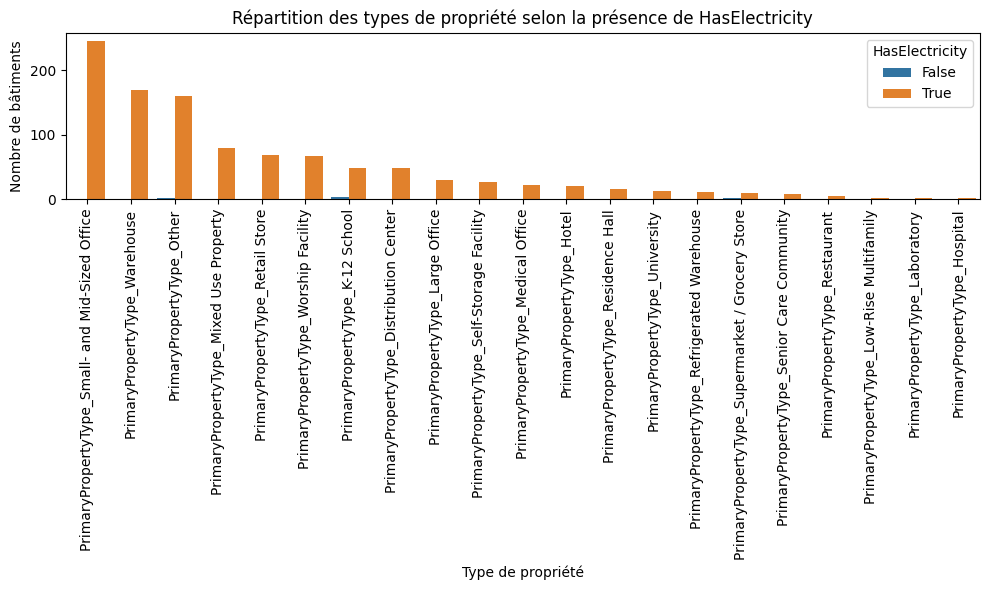

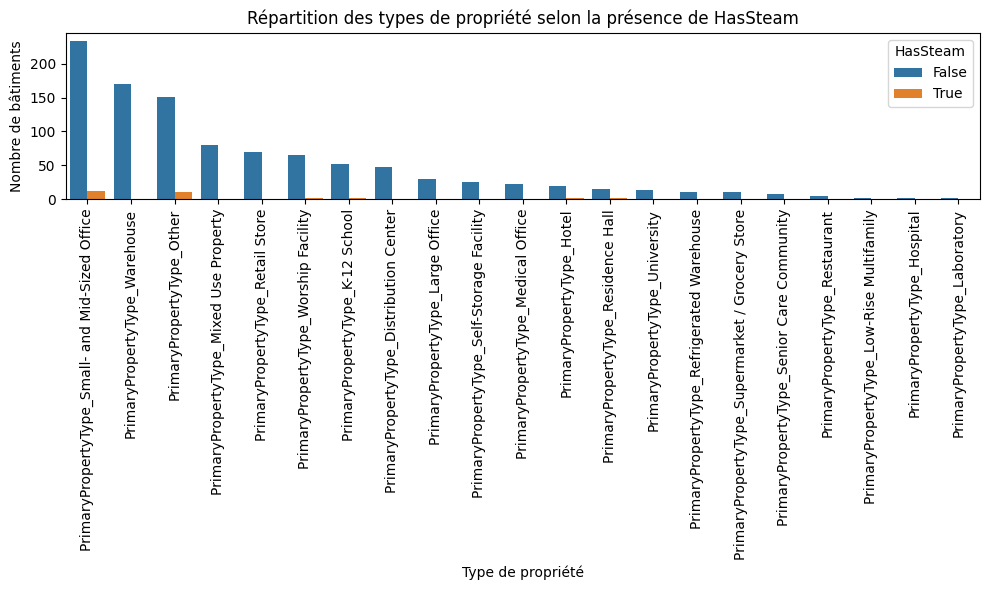

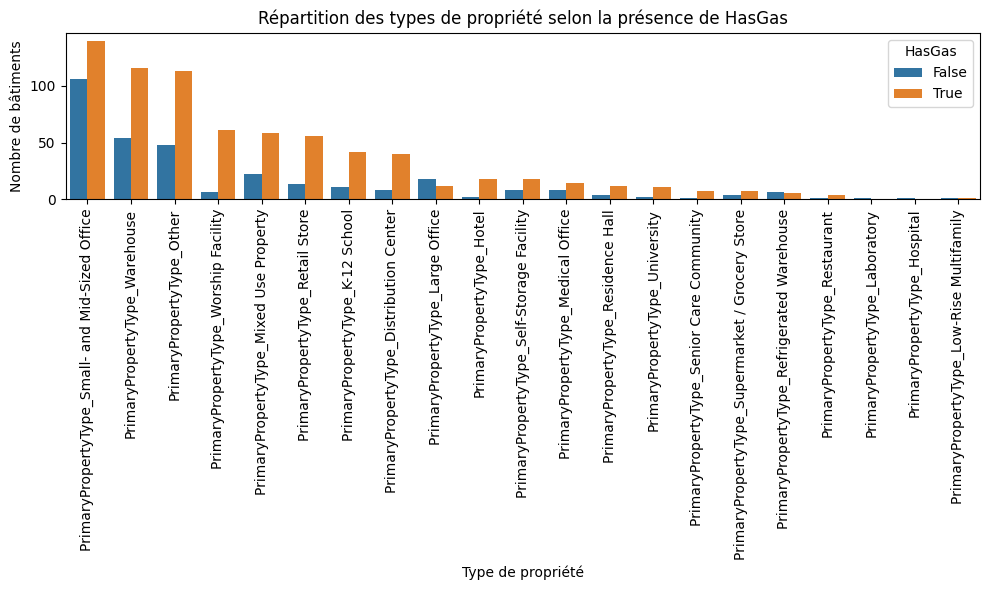

In [143]:
for var in energy_cols:
    energy_var = var

    # Préparation du DataFrame en format long
    df_melted = NR_building_consumption.melt(
        id_vars=[energy_var],
        value_vars=PrimaryPropertyType_cols,
        var_name='PropertyType',
        value_name='Presence'
    )

    # Filtrer uniquement les lignes où Presence == 1
    df_filtered = df_melted[df_melted['Presence'] == 1]

    # Grouper par type de propriété et présence d'énergie
    grouped = df_filtered.groupby(['PropertyType', energy_var]).size().reset_index(name='Count').sort_values(by='Count',ascending=False)

    # Tracé du barplot avec hue pour empiler
    plt.figure(figsize=(10, 6))
    sns.barplot(data=grouped, x='PropertyType', y='Count', hue=energy_var)
    plt.title(f"Répartition des types de propriété selon la présence de {energy_var}")
    plt.xlabel("Type de propriété")
    plt.ylabel("Nombre de bâtiments")
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()


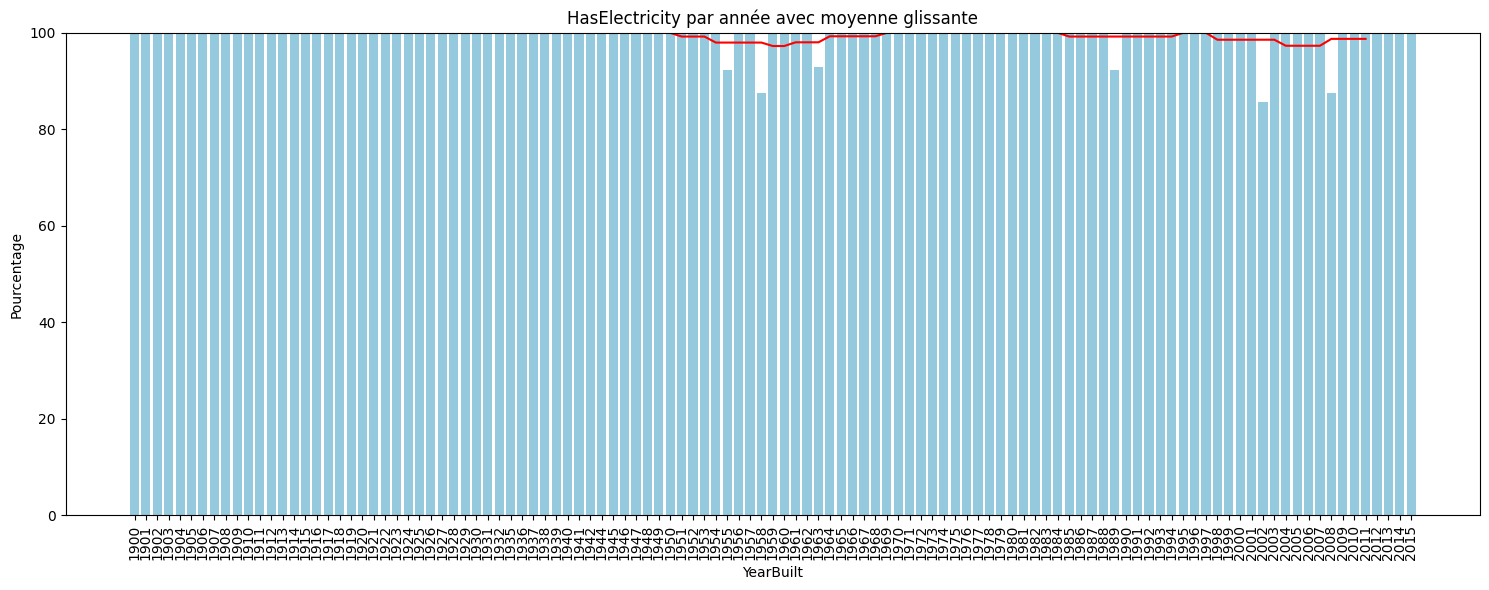

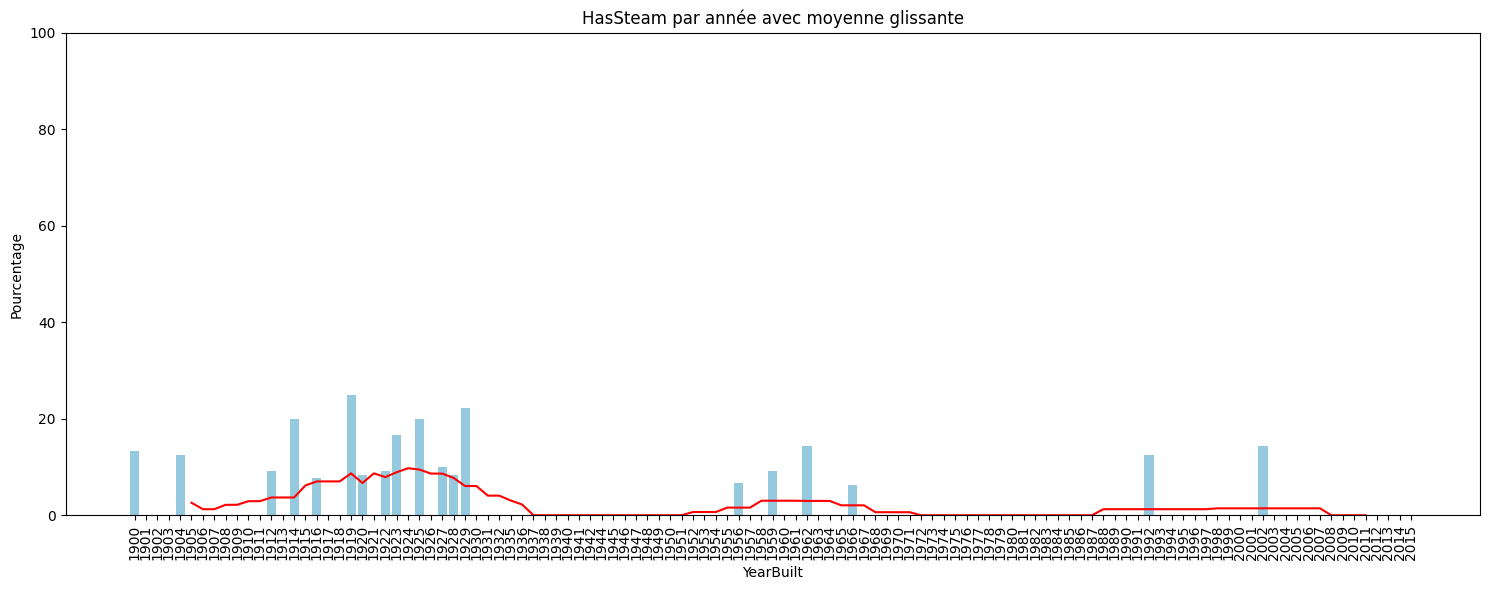

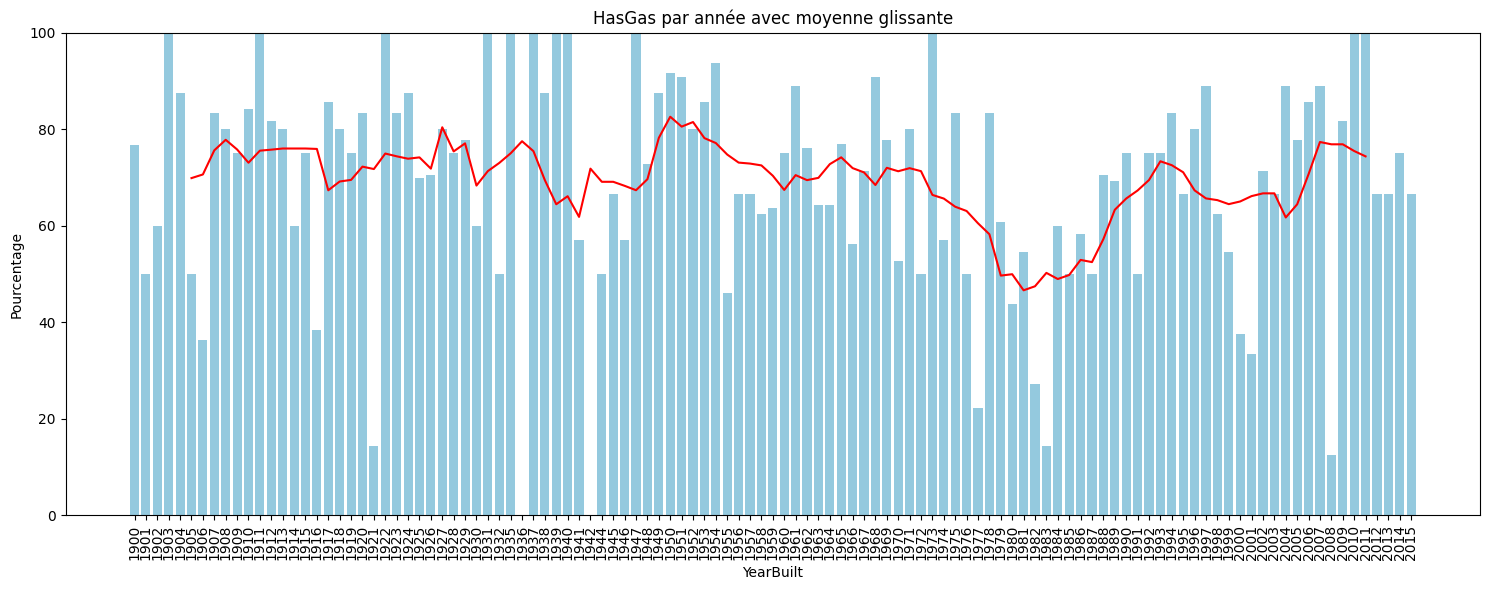

In [144]:
energies = ['HasElectricity','HasSteam','HasGas']

Energy_per_year = NR_building_consumption[['YearBuilt','HasElectricity','HasSteam','HasGas']]
total_bat = Energy_per_year.groupby('YearBuilt').size().reset_index(name='Total')
Energy_per_year = Energy_per_year.groupby('YearBuilt').sum().reset_index()
Energy_per_year_percentage = Energy_per_year.merge(total_bat,on='YearBuilt')
Energy_per_year_percentage[energies] = Energy_per_year_percentage[energies].apply(lambda x : x / Energy_per_year_percentage['Total']*100)
for energy in energies:
    Energy_per_year_percentage[f'10Years_rolling_{energy}'] = Energy_per_year_percentage[energy].rolling(window=10, center=True).mean()

    Energy_per_year_percentage['YearBuilt'] = Energy_per_year_percentage['YearBuilt'].astype(str)



    fig, ax = plt.subplots(figsize=(15, 6))

    # Barplot
    sns.barplot(data=Energy_per_year_percentage, x='YearBuilt', y=energy, ax=ax, color='skyblue')

    # Lineplot
    sns.lineplot(data=Energy_per_year_percentage, x='YearBuilt', y=f'10Years_rolling_{energy}', ax=ax, color='red')

    # Contraindre les limites de l'axe Y
    ax.set_ylim(0, 100)  # Par exemple, si tu veux afficher des pourcentages

    # Améliorer la lisibilité
    ax.set_ylabel('Pourcentage')
    plt.title(f"{energy} par année avec moyenne glissante")
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()




**Conclusion :**  
On constate 3 choses :
 - Pratiquement tous les batiments ont de l'electricité
 - Très peu de batiment ont de la vapeur
 - La répartition de présence de gaz est différente selon le type de batiment

On sait aussi que dépendement de l'année de construction, les batiments ont plus ou moins accès à la vapeur et au gaz

## Séparation du jeu de donnée en X et y

In [145]:
y = NR_building_consumption['TotalGHGEmissions']
X = NR_building_consumption.drop('TotalGHGEmissions', axis=1)

In [146]:
y.head()

25      9.13
28      0.00
29    128.44
31     10.43
32    157.77
Name: TotalGHGEmissions, dtype: float64

In [147]:
X.head()

,CouncilDistrictCode,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFABuilding(s),ENERGYSTARScore,BuildingType_Campus,BuildingType_NonResidential,...,Neighborhood_NORTH,Neighborhood_NORTHEAST,Neighborhood_NORTHWEST,Neighborhood_SOUTHEAST,Neighborhood_SOUTHWEST,HasElectricity,HasSteam,HasGas,isMultiUsage,HasParking
25,7,47.61500,-122.33081,1930,1.0,2,67224,NaN,False,True,...,False,False,False,False,False,True,False,False,False,False
28,3,47.62266,-122.30547,1955,1.0,1,126351,NaN,False,False,...,False,False,False,False,False,False,False,False,False,False
29,7,47.61558,-122.34186,1978,1.0,5,52210,57.0,False,True,...,False,False,False,False,False,True,False,True,False,True
31,7,47.63290,-122.35172,1989,1.0,2,51582,NaN,False,False,...,False,False,False,False,False,True,False,False,False,False
32,4,47.66410,-122.33118,1906,1.0,3,87262,NaN,False,True,...,False,False,False,False,False,True,False,True,True,False


# Comparaison de différents modèles supervisés

A réaliser :
* Pour chaque algorithme que vous allez tester, vous devez :
    * Réaliser au préalable une séparation en jeu d'apprentissage et jeu de test via une validation croisée.
    * Si les features quantitatives que vous souhaitez utiliser ont des ordres de grandeur très différents les uns des autres, et que vous utilisez un algorithme de regression qui est sensible à cette différence, alors il faut réaliser un scaling (normalisation) de la donnée au préalable.
    * Entrainer le modèle sur le jeu de Train
    * Prédire la cible sur la donnée de test (nous appelons cette étape, l'inférence).
    * Calculer les métriques de performance R2, MAE et RMSE sur le jeu de train et de test.
    * Interpréter les résultats pour juger de la fiabilité de l'algorithme.
* Vous pouvez choisir par exemple de tester un modèle linéaire, un modèle à base d'arbres et un modèle de type SVM
* Déterminer le modèle le plus performant parmi ceux testés.

## Normalisation des variables quantitatives

In [178]:
from scipy import stats
from sklearn.preprocessing import PowerTransformer, QuantileTransformer
from scipy.stats import shapiro

Text(0.5, 1.0, 'log : Skewness = -0.6849402479356652 | Kurtosis = 0.3456827561164255')

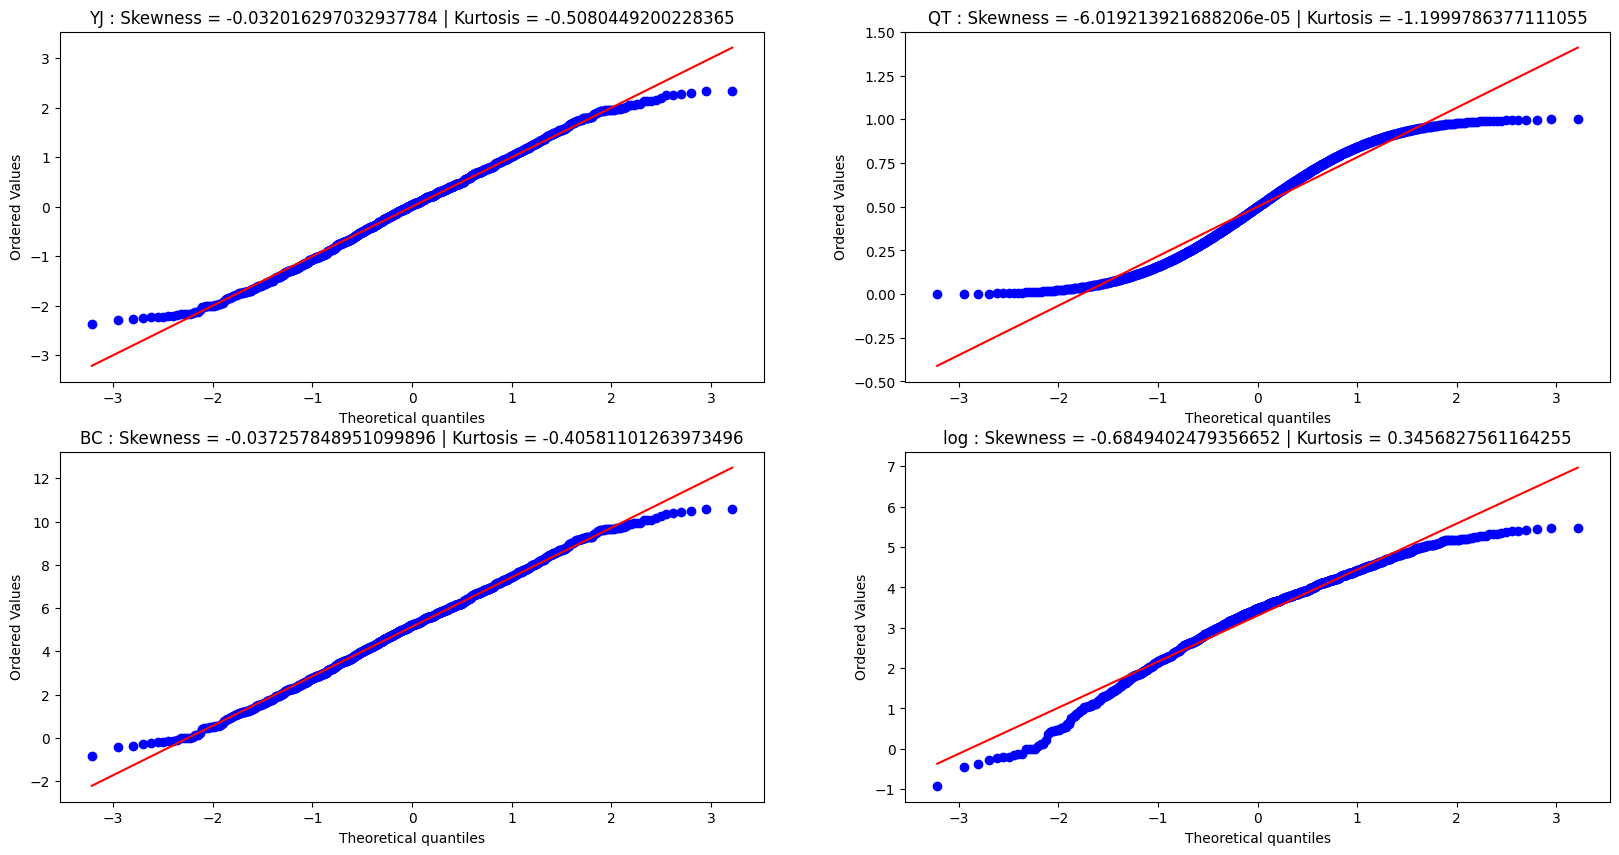

In [173]:
numerical_values = ['TotalGHGEmissions','PropertyGFABuilding(s)','ENERGYSTARScore']
df_numerical_TotalGHGEmissions = pd.DataFrame(NR_building_consumption.loc[:,'TotalGHGEmissions'])

df_numerical_TotalGHGEmissions['TotalGHGEmissions'] = df_numerical_TotalGHGEmissions['TotalGHGEmissions'].replace(0,1)

pt = PowerTransformer(method='yeo-johnson')
qt = QuantileTransformer()

plt.figure(figsize=(20,10))
df_numerical_TotalGHGEmissions['yj'] = pt.fit_transform(df_numerical_TotalGHGEmissions['TotalGHGEmissions'].values.reshape(-1,1))
yj_comment = f"YJ : Skewness = {df_numerical_TotalGHGEmissions['yj'].skew()} | Kurtosis = {df_numerical_TotalGHGEmissions['yj'].kurt()}"
plt.subplot(2,2,1)

stats.probplot(df_numerical_TotalGHGEmissions['yj'], dist='norm', plot=plt)
plt.title(yj_comment)

df_numerical_TotalGHGEmissions['qt'] = qt.fit_transform(df_numerical_TotalGHGEmissions['TotalGHGEmissions'].values.reshape(-1,1))
qt_comment = f"QT : Skewness = {df_numerical_TotalGHGEmissions['qt'].skew()} | Kurtosis = {df_numerical_TotalGHGEmissions['qt'].kurt()}"
plt.subplot(2,2,2)

stats.probplot(df_numerical_TotalGHGEmissions['qt'], dist='norm', plot=plt)
plt.title(qt_comment)

df_numerical_TotalGHGEmissions['bc'], delta = stats.boxcox(df_numerical_TotalGHGEmissions['TotalGHGEmissions'])
bc_comment = f"BC : Skewness = {df_numerical_TotalGHGEmissions['bc'].skew()} | Kurtosis = {df_numerical_TotalGHGEmissions['bc'].kurt()}"
plt.subplot(2,2,3)

stats.probplot(df_numerical_TotalGHGEmissions['bc'], dist='norm', plot=plt)
plt.title(bc_comment)

df_numerical_TotalGHGEmissions['log'] = np.log(df_numerical_TotalGHGEmissions['TotalGHGEmissions'])
log_comment = f"log : Skewness = {df_numerical_TotalGHGEmissions['log'].skew()} | Kurtosis = {df_numerical_TotalGHGEmissions['log'].kurt()}"
plt.subplot(2,2,4)

stats.probplot(df_numerical_TotalGHGEmissions['log'], dist='norm', plot=plt,)
plt.title(log_comment)





**Conclusion :** On utilisera le boxcox pour TotalGHGEmissions

Text(0.5, 1.0, 'log : Skewness = 0.5037762088999117 | Kurtosis = -0.49713804606959666')

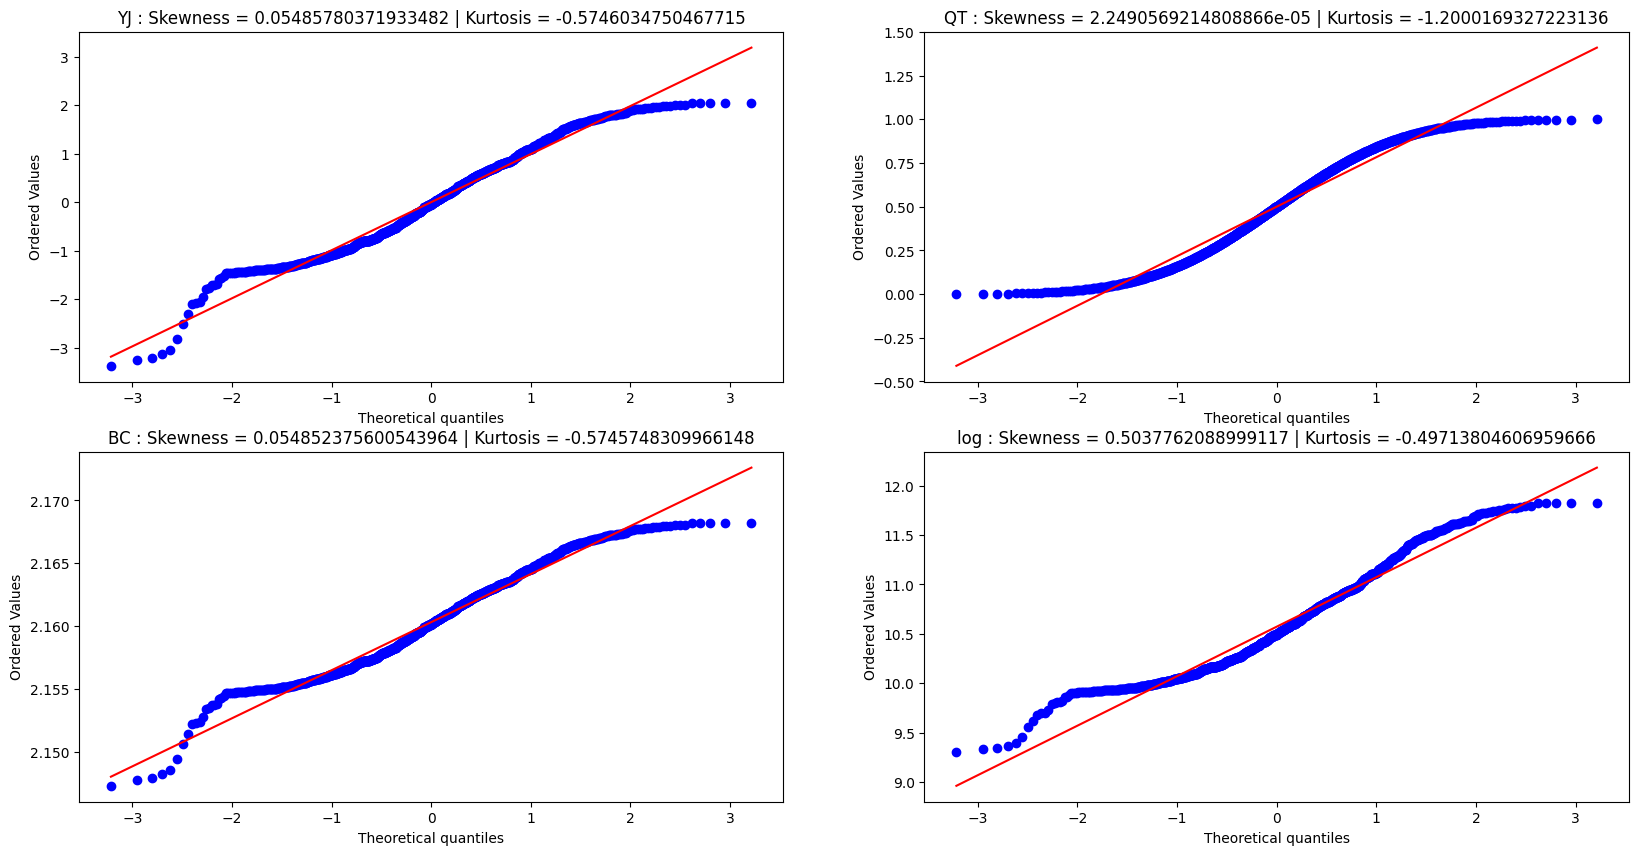

In [174]:
df_numerical_PropertyGFABuilding = pd.DataFrame(NR_building_consumption.loc[:,'PropertyGFABuilding(s)'])

df_numerical_PropertyGFABuilding['PropertyGFABuilding(s)'] = df_numerical_PropertyGFABuilding['PropertyGFABuilding(s)'].replace(0,1)

pt = PowerTransformer(method='yeo-johnson')
qt = QuantileTransformer()

plt.figure(figsize=(20,10))
df_numerical_PropertyGFABuilding['yj'] = pt.fit_transform(df_numerical_PropertyGFABuilding['PropertyGFABuilding(s)'].values.reshape(-1,1))
yj_comment = f"YJ : Skewness = {df_numerical_PropertyGFABuilding['yj'].skew()} | Kurtosis = {df_numerical_PropertyGFABuilding['yj'].kurt()}"
plt.subplot(2,2,1)

stats.probplot(df_numerical_PropertyGFABuilding['yj'], dist='norm', plot=plt)
plt.title(yj_comment)

df_numerical_PropertyGFABuilding['qt'] = qt.fit_transform(df_numerical_PropertyGFABuilding['PropertyGFABuilding(s)'].values.reshape(-1,1))
qt_comment = f"QT : Skewness = {df_numerical_PropertyGFABuilding['qt'].skew()} | Kurtosis = {df_numerical_PropertyGFABuilding['qt'].kurt()}"
plt.subplot(2,2,2)

stats.probplot(df_numerical_PropertyGFABuilding['qt'], dist='norm', plot=plt)
plt.title(qt_comment)

df_numerical_PropertyGFABuilding['bc'], delta = stats.boxcox(df_numerical_PropertyGFABuilding['PropertyGFABuilding(s)'])
bc_comment = f"BC : Skewness = {df_numerical_PropertyGFABuilding['bc'].skew()} | Kurtosis = {df_numerical_PropertyGFABuilding['bc'].kurt()}"
plt.subplot(2,2,3)

stats.probplot(df_numerical_PropertyGFABuilding['bc'], dist='norm', plot=plt)
plt.title(bc_comment)

df_numerical_PropertyGFABuilding['log'] = np.log(df_numerical_PropertyGFABuilding['PropertyGFABuilding(s)'])
log_comment = f"log : Skewness = {df_numerical_PropertyGFABuilding['log'].skew()} | Kurtosis = {df_numerical_PropertyGFABuilding['log'].kurt()}"
plt.subplot(2,2,4)

stats.probplot(df_numerical_PropertyGFABuilding['log'], dist='norm', plot=plt,)
plt.title(log_comment)


**Conclusion :** On utilisera le boxcox pour PropertyGFABuilding(s)

Text(0.5, 1.0, 'log : Skewness = -2.3255717666133595 | Kurtosis = 5.51664646478646')

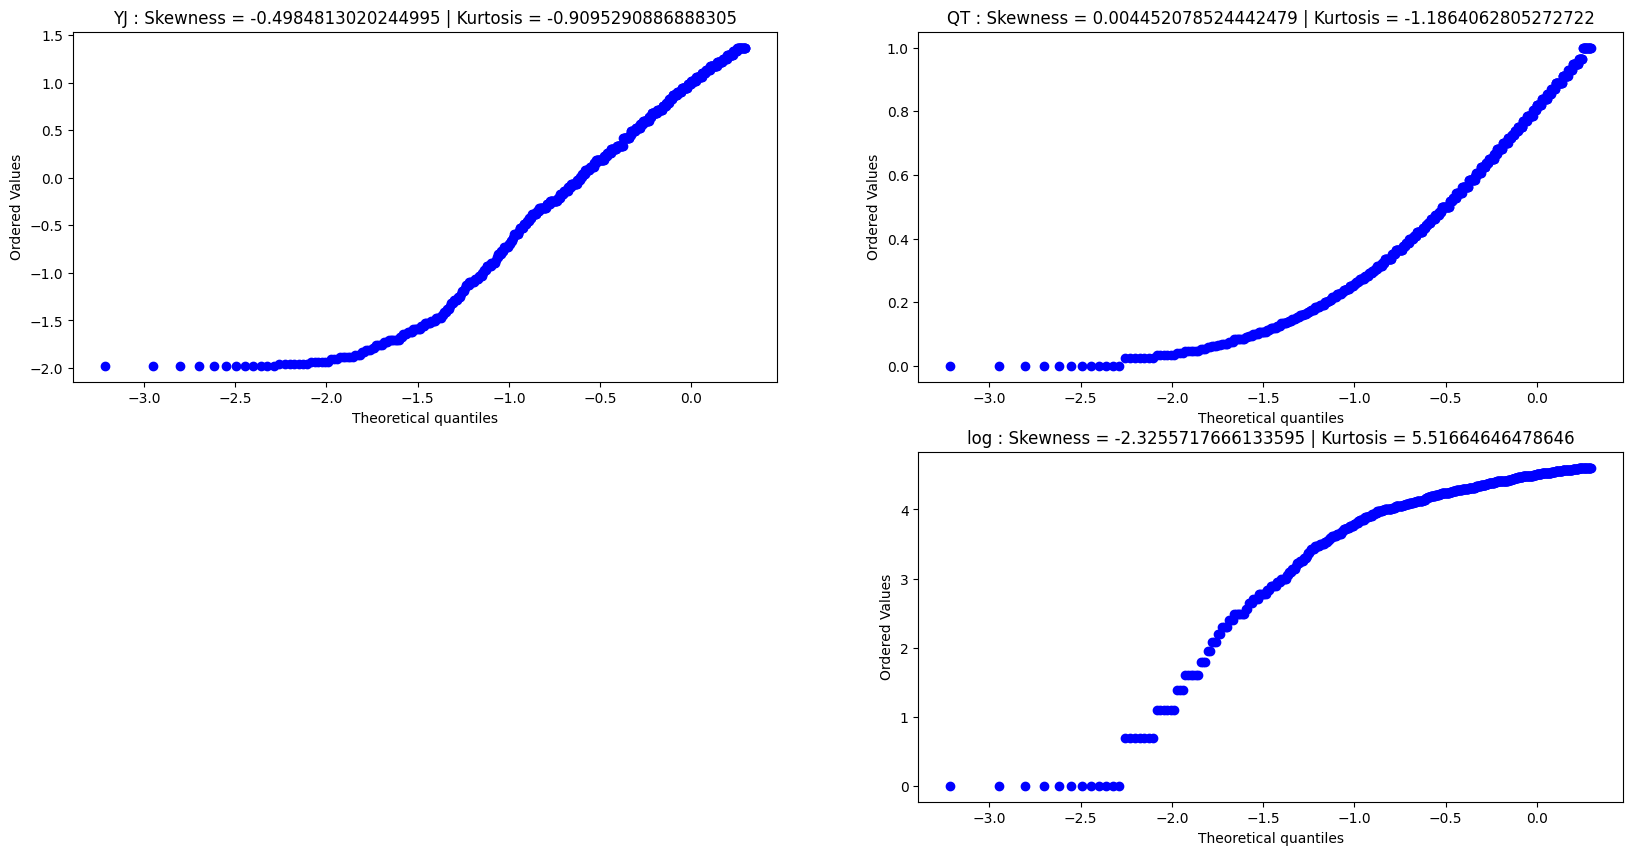

In [175]:
df_numerical_ENERGYSTARScore = pd.DataFrame(NR_building_consumption.loc[:,'ENERGYSTARScore'])

df_numerical_ENERGYSTARScore['ENERGYSTARScore'] = df_numerical_ENERGYSTARScore['ENERGYSTARScore'].replace(0,1)

pt = PowerTransformer(method='yeo-johnson')
qt = QuantileTransformer()

plt.figure(figsize=(20,10))
df_numerical_ENERGYSTARScore['yj'] = pt.fit_transform(df_numerical_ENERGYSTARScore['ENERGYSTARScore'].values.reshape(-1,1))
yj_comment = f"YJ : Skewness = {df_numerical_ENERGYSTARScore['yj'].skew()} | Kurtosis = {df_numerical_ENERGYSTARScore['yj'].kurt()}"
plt.subplot(2,2,1)

stats.probplot(df_numerical_ENERGYSTARScore['yj'], dist='norm', plot=plt)
plt.title(yj_comment)

df_numerical_ENERGYSTARScore['qt'] = qt.fit_transform(df_numerical_ENERGYSTARScore['ENERGYSTARScore'].values.reshape(-1,1))
qt_comment = f"QT : Skewness = {df_numerical_ENERGYSTARScore['qt'].skew()} | Kurtosis = {df_numerical_ENERGYSTARScore['qt'].kurt()}"
plt.subplot(2,2,2)

stats.probplot(df_numerical_ENERGYSTARScore['qt'], dist='norm', plot=plt)
plt.title(qt_comment)

df_numerical_ENERGYSTARScore['log'] = np.log(df_numerical_ENERGYSTARScore['ENERGYSTARScore'])
log_comment = f"log : Skewness = {df_numerical_ENERGYSTARScore['log'].skew()} | Kurtosis = {df_numerical_ENERGYSTARScore['log'].kurt()}"
plt.subplot(2,2,4)

stats.probplot(df_numerical_ENERGYSTARScore['log'], dist='norm', plot=plt,)
plt.title(log_comment)

In [179]:

stat, p = shapiro(df_numerical_TotalGHGEmissions['bc'])
print(f"Shapiro-Wilk : stat={stat:.4f}, p-value={p:.4f}")


Shapiro-Wilk : stat=0.9952, p-value=0.0019


In [180]:

stat, p = shapiro(df_numerical_PropertyGFABuilding['bc'])
print(f"Shapiro-Wilk : stat={stat:.4f}, p-value={p:.4f}")


Shapiro-Wilk : stat=0.9755, p-value=0.0000


In [176]:
df_buildings_consumption_norm = NR_building_consumption
df_buildings_consumption_norm['PropertyGFABuilding(s)'] = df_numerical_PropertyGFABuilding['bc']
df_buildings_consumption_norm['TotalGHGEmissions'] = df_numerical_TotalGHGEmissions['bc']
df_buildings_consumption_norm.head()

,CouncilDistrictCode,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFABuilding(s),ENERGYSTARScore,TotalGHGEmissions,BuildingType_Campus,...,Neighborhood_NORTH,Neighborhood_NORTHEAST,Neighborhood_NORTHWEST,Neighborhood_SOUTHEAST,Neighborhood_SOUTHWEST,HasElectricity,HasSteam,HasGas,isMultiUsage,HasParking
25,7,47.61500,-122.33081,1930,1.0,2,2.164510,NaN,2.846929,False,...,False,False,False,False,False,True,False,False,False,False
28,3,47.62266,-122.30547,1955,1.0,1,2.167836,NaN,0.000000,False,...,False,False,False,False,False,False,False,False,False,False
29,7,47.61558,-122.34186,1978,1.0,5,2.162883,57.0,8.670531,False,...,False,False,False,False,False,True,False,True,False,True
31,7,47.63290,-122.35172,1989,1.0,2,2.162801,NaN,3.066435,False,...,False,False,False,False,False,True,False,False,False,False
32,4,47.66410,-122.33118,1906,1.0,3,2.166003,NaN,9.281365,False,...,False,False,False,False,False,True,False,True,True,False


### Optimisation et interprétation du modèle

A réaliser :
* Reprennez le meilleur algorithme que vous avez sécurisé via l'étape précédente, et réalisez une GridSearch de petite taille sur au moins 3 hyperparamètres.
* Si le meilleur modèle fait partie de la famille des modèles à arbres (RandomForest, GradientBoosting) alors utilisez la fonctionnalité feature importance pour identifier les features les plus impactantes sur la performance du modèle. Sinon, utilisez la méthode Permutation Importance de sklearn.

In [177]:
# CODE OPTIMISATION ET INTERPRETATION DU MODELE